# Forward Models

A neural-mass model evolves *hidden* dynamics -- firing rates, synaptic gating, membrane
potentials. None of those are what an experiment actually records. A **forward model** (or
*observation model*) is the biophysical map from that hidden activity to a measurable
neuroimaging signal:

```text
Neural-mass model  ->  Forward model  ->  Observable signal
(hidden dynamics)      (biophysics)       (BOLD / EEG / MEG)
```

This is the bridge that turns a simulation into something you can compare against data --
the prerequisite for the *fitting* and *training* tutorials that follow. In this notebook you
will:

1. build a small multi-region source with {class}`~brainmass.Network` and a bundled
   connectome,
2. map excitatory activity to **fMRI BOLD** two ways -- the convolution
   {class}`~brainmass.HRFBold` and the Balloon--Windkessel {class}`~brainmass.BOLDSignal`,
3. project a millisecond-scale cortical source to **EEG** and **MEG** sensors through
   unit-aware lead-field operators, and
4. read out and visualise each modality with {mod}`brainmass.viz`.

:::{note}
Every cell runs against the current API. The connectivity and lead-field matrices are small
synthetic stand-ins so the page builds fast -- swap in your own structural connectome and
BEM-derived lead fields for a real study.
:::

In [1]:
import brainmass
import brainstate
import braintools
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# A delay-coupled Network sizes its delay buffer from the global dt at construction,
# so set dt once here, before building any Network.
brainstate.environ.set(dt=1.0 * u.ms)
brainstate.random.seed(0)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A multi-region source

BOLD and EEG/MEG both observe the activity of *many* regions, so we first build a small
whole-brain source. We load the bundled 8-region example connectome and wire it into a
{class}`~brainmass.Network` of {class}`~brainmass.WilsonCowanStep` nodes. Per-region
Ornstein--Uhlenbeck noise (`noise_E=...`) gives each region its own fluctuations -- without
it a deterministic network collapses to one shared fixed point and the observed signals would
be perfectly correlated (a degenerate functional connectivity).

connectome: 8 regions, labels = [np.str_('R0'), np.str_('R1'), np.str_('R2'), np.str_('R3'), np.str_('R4'), np.str_('R5'), np.str_('R6'), np.str_('R7')]


neural source: (5500, 8) | unit: 1


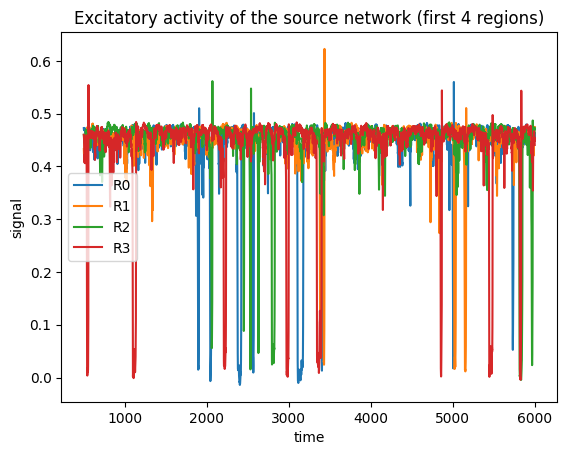

In [2]:
conn = brainmass.datasets.load_dataset('example_connectome')
N = conn.weights.shape[0]
labels = list(conn.labels)
print(f"connectome: {N} regions, labels = {labels}")

node = brainmass.WilsonCowanStep(
    in_size=N,
    noise_E=brainmass.OUProcess(N, sigma=0.4, tau=20.0 * u.ms),
)
net = brainmass.Network(
    node,
    conn=conn.weights,
    distance=conn.distances,
    speed=10.0 * u.mm / u.ms,
    coupling='diffusive',
    coupled_var='rE',
    k=0.5,
)

# Run the source network; monitor each region's excitatory rate rE.
src = brainmass.Simulator(net, dt=1.0 * u.ms).run(
    6000.0 * u.ms,
    monitors=lambda m: m.node.rE.value,
    transient=500.0 * u.ms,
)
neural = src['output']          # (T, N) excitatory rate (dimensionless WilsonCowan rate)
ts = src['ts']
print("neural source:", neural.shape, "| unit:", u.get_unit(neural))

ax = brainmass.viz.plot_timeseries(neural[:, :4], ts=ts, labels=labels[:4])
ax.set_title("Excitatory activity of the source network (first 4 regions)")
plt.show()

## BOLD: from neural activity to fMRI

The fMRI BOLD signal is the **hemodynamic** response to neural activity -- slow (timescale of
seconds) and lagged. brainmass ships two forward models; they trade speed and
differentiability against biophysical detail.

### Convolution BOLD ({class}`~brainmass.HRFBold`)

`HRFBold` convolves the neural drive with a hemodynamic response function (HRF) kernel and
downsamples to the fMRI repetition time (TR). It is a single linear convolution -- fast and
**differentiable in its scalar parameters** -- which makes it the natural choice when BOLD is
the target of a *fit*. Several closed-form kernels are available
({class}`~brainmass.GammaHRFKernel`, {class}`~brainmass.DoubleExponentialHRFKernel`,
{class}`~brainmass.MixtureOfGammasHRFKernel`, ...).

HRFBold BOLD: (7, 8)


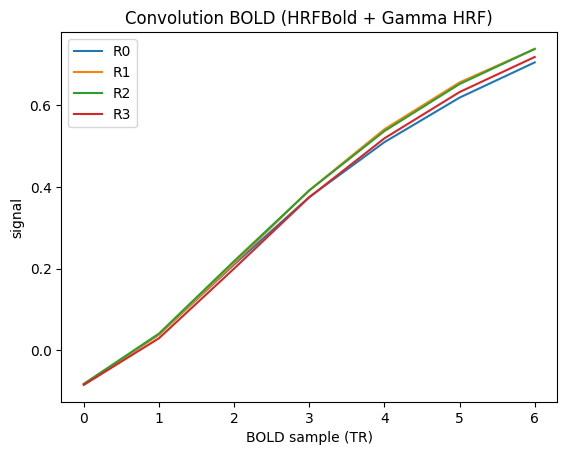

In [3]:
hrf = brainmass.HRFBold(
    period=720.0 * u.ms,            # output TR (~0.72 s, a fast multiband protocol)
    downsample_period=20.0 * u.ms,  # internal convolution step
    kernel=brainmass.GammaHRFKernel(),
)
bold_conv = hrf(u.get_magnitude(neural), dt=1.0 * u.ms)   # (T_bold, N), dimensionless
print("HRFBold BOLD:", bold_conv.shape)

ax = brainmass.viz.plot_timeseries(bold_conv[:, :4], labels=labels[:4])
ax.set_xlabel("BOLD sample (TR)")
ax.set_title("Convolution BOLD (HRFBold + Gamma HRF)")
plt.show()

### Balloon--Windkessel BOLD ({class}`~brainmass.BOLDSignal`)

`BOLDSignal` integrates the four-state Balloon--Windkessel ODE (blood volume, flow,
deoxyhemoglobin) -- the choice when biophysical realism matters. It is *dimensionless* and its
RK2 integrator advances `t + dt`, so it needs a **unitless** `dt` in `environ` (a `Quantity`
`dt` would raise on `ms + 1`). We therefore drive it with `dt = 0.01` while the neural stage
used `1.0 * u.ms`; restore the time-unit `dt` afterwards.

BOLDSignal BOLD: (5500, 8)


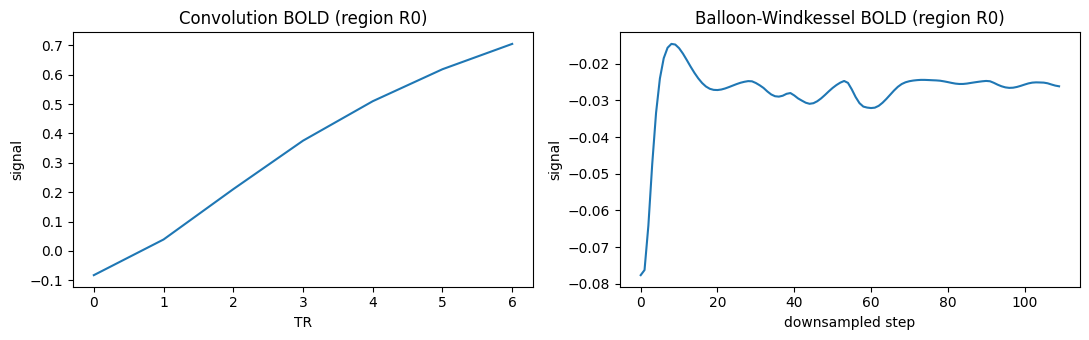

In [4]:
brainstate.environ.set(dt=0.01)            # dimensionless dt for the haemodynamic ODE
bold_model = brainmass.BOLDSignal(in_size=N)
bold_model.init_all_states()

def bold_step(z):
    bold_model.update(z)
    return bold_model.bold()

bold_balloon = brainstate.transform.for_loop(bold_step, u.get_magnitude(neural))  # (T, N)
brainstate.environ.set(dt=1.0 * u.ms)      # restore the time-unit dt

print("BOLDSignal BOLD:", bold_balloon.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
brainmass.viz.plot_timeseries(bold_conv[:, 0], ax=axes[0])
axes[0].set_title("Convolution BOLD (region R0)")
axes[0].set_xlabel("TR")
brainmass.viz.plot_timeseries(bold_balloon[::50, 0], ax=axes[1])
axes[1].set_title("Balloon-Windkessel BOLD (region R0)")
axes[1].set_xlabel("downsampled step")
plt.tight_layout()
plt.show()

Both BOLD pipelines track the same slow envelope of the neural drive; they differ in their
intrinsic hemodynamic latency, so compare BOLD waveforms over a small lag rather than at
exact zero lag. Use `HRFBold` for fast, differentiable fitting and `BOLDSignal` when you need
the full Balloon--Windkessel biophysics.

## EEG and MEG: lead-field forward models

EEG and MEG are *instantaneous* linear projections of cortical dipole activity onto sensors.
The **lead field** `L` is the gain matrix that maps each region's dipole moment to each
sensor. brainmass provides unit-aware operators that carry the physics:

- {class}`~brainmass.EEGLeadFieldModel` -- scalp potentials in **volts**,
- {class}`~brainmass.MEGLeadFieldModel` / {class}`~brainmass.LeadFieldModel` -- magnetic
  fields in **tesla**.

We use a {class}`~brainmass.JansenRitStep` source whose pyramidal observable
(`jr.eeg()`, the classic EEG correlate) is a millisecond-scale membrane potential in **mV** --
exactly the kind of fast signal EEG/MEG record.

In [5]:
R, M = 4, 6   # 4 cortical sources, 6 sensors

jr = brainmass.JansenRitStep(in_size=R)
eeg_src = brainmass.Simulator(jr, dt=0.1 * u.ms).run(
    400.0 * u.ms,
    monitors=lambda m: m.eeg(),     # pyramidal observable, shape (T, R), in mV
    transient=100.0 * u.ms,
)['output']
print("Jansen-Rit source:", eeg_src.shape, "| unit:", u.get_unit(eeg_src))

rng = np.random.RandomState(1)

# EEG lead field: gain in volt / (nA*m); the helper assumes an mV source.
L_eeg = jnp.asarray(rng.rand(R, M)) * (u.volt / (u.nA * u.meter))
eeg_model = brainmass.EEGLeadFieldModel(in_size=(R,), out_size=(M,), L=L_eeg, sensor_unit=u.volt)
eeg = eeg_model.update(eeg_src)     # (T, M) in volts

# MEG lead field: gain in tesla / (nA*m). We use the base LeadFieldModel with an explicit
# `scale` so the mV source is converted to a dipole moment before projection.
L_meg = jnp.asarray(rng.rand(R, M)) * (u.tesla / (u.nA * u.meter))
meg_model = brainmass.LeadFieldModel(
    in_size=(R,), out_size=(M,), L=L_meg,
    sensor_unit=u.tesla, dipole_unit=u.nA * u.meter, scale=u.nA * u.meter / u.mV,
)
meg = meg_model.update(eeg_src)     # (T, M) in tesla

print("EEG sensors:", eeg.shape, "| unit:", u.get_unit(eeg))
print("MEG sensors:", meg.shape, "| unit:", u.get_unit(meg))

Jansen-Rit source: (3000, 4) | unit: mV
EEG sensors: (3000, 6) | unit: V
MEG sensors: (3000, 6) | unit: T


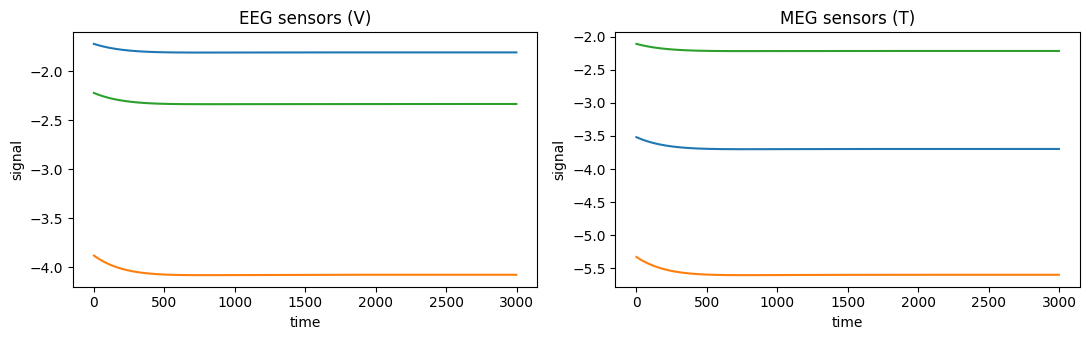

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
brainmass.viz.plot_timeseries(eeg[:, :3], ax=axes[0])
axes[0].set_title("EEG sensors (V)")
brainmass.viz.plot_timeseries(meg[:, :3], ax=axes[1])
axes[1].set_title("MEG sensors (T)")
plt.tight_layout()
plt.show()

### Inspecting the spectrum

A forward model preserves the temporal structure of its source. Estimating the power spectrum
of one EEG channel confirms the signal carries the source's oscillatory content (the
Jansen--Rit alpha rhythm). The Jansen--Rit stage used `dt = 0.1 ms`, i.e. a 10 kHz sampling
rate.

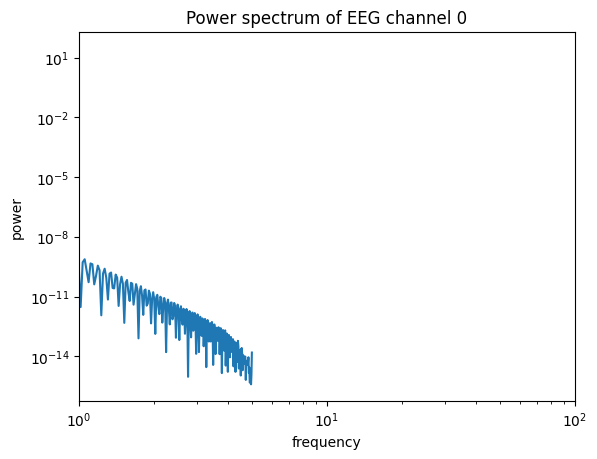

In [7]:
ax = brainmass.viz.plot_power_spectrum(eeg[:, 0], dt=0.1 * u.ms)
ax.set_title("Power spectrum of EEG channel 0")
ax.set_xlim(1, 100)
plt.show()

## Validating against data: functional connectivity

A common way to score a whole-brain model is the agreement between its **functional
connectivity** (FC, the region x region correlation of the observed signal) and an empirical
FC. We compute the BOLD FC from the convolution pipeline and compare it to the FC bundled with
the example signal dataset, using the same correlation that {mod}`brainmass.objectives` will
optimise in the next tutorial.

FC(simulated BOLD) vs FC(empirical): correlation = 0.101


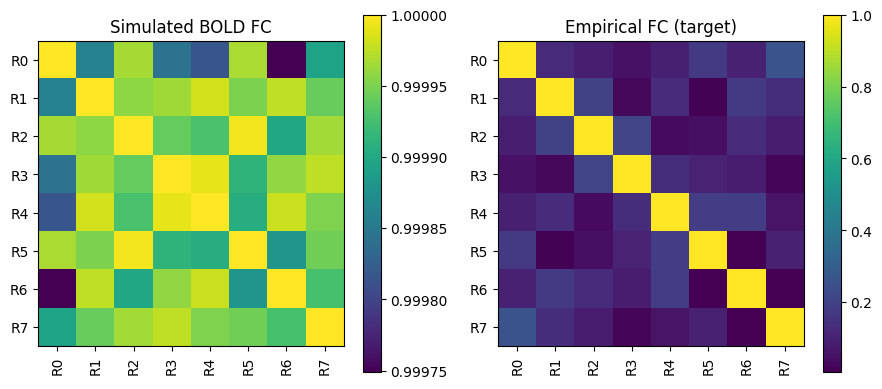

In [8]:
sig = brainmass.datasets.load_dataset('example_signal')
fc_target = sig.fc                                  # (N, N) "empirical" FC

fc_corr = brainmass.objectives.fc_corr()            # builder -> callable(pred, target)
score = float(fc_corr(bold_conv, fc_target))        # Pearson corr between the two FC matrices
print(f"FC(simulated BOLD) vs FC(empirical): correlation = {score:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
brainmass.viz.plot_functional_connectivity(bold_conv, labels=labels, ax=axes[0])
axes[0].set_title("Simulated BOLD FC")
brainmass.viz.plot_functional_connectivity(fc_target, is_matrix=True, labels=labels, ax=axes[1])
axes[1].set_title("Empirical FC (target)")
plt.tight_layout()
plt.show()

That single scalar -- the FC correlation -- is exactly the kind of *summary* objective the
fitter minimises. Driving it up by adjusting model parameters is the subject of the next
tutorial.

## Summary

- A **forward model** maps hidden neural dynamics to an observable signal.
- {class}`~brainmass.HRFBold` (fast, differentiable convolution) and
  {class}`~brainmass.BOLDSignal` (Balloon--Windkessel ODE) both turn neural activity into
  **BOLD**; pick the former for fitting, the latter for biophysical realism.
- {class}`~brainmass.EEGLeadFieldModel` and {class}`~brainmass.LeadFieldModel` project a
  cortical source to **EEG (volts)** and **MEG (tesla)** through a unit-aware lead field.
- {mod}`brainmass.objectives` turns a prediction-vs-data comparison (e.g. FC correlation) into
  a single scalar -- the bridge to fitting.

## Next steps

- {doc}`/tutorials/06_fitting_with_gradients` -- fit model parameters to an observed signal by
  backpropagating through the solve.
- {doc}`/tutorials/07_gradient_free_fitting` -- the same fit with gradient-free search.
- {doc}`/reference/forward` -- complete forward-model and lead-field API.
- {doc}`/reference/observation` -- HRF kernels and observation models.